<a href="https://colab.research.google.com/github/YYChang34/Time-Series-Forecasting-with-LSTM-and-GRU/blob/main/Time_Series_Forecasting_with_LSTM_and_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Time Series Forecasting with LSTM and GRU

# Data Preprocessing

- Step 1:匯入Daily Temperature Time-Series Data包含1981年至1990年澳大利亞墨爾本的每日溫度測量結果。
- Step 2:使用 MinMaxScaler 將數據轉換到[0, 1]的範圍內，有助於提高訓練的效率和模型的性能。
- Step 3:設置window_size為 15，即每次模型將根據過去 15 天的數據來預測第 16 天的數據。create_sequences 函數會根據這個大小從 Daily Temperature Time-Series Data 中創建對應的 x 和 y 序列。
- Step 4:將dataset分割成 80% train dataset & 20% test dataset。




In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data = pd.read_csv(url, parse_dates=['Date'], index_col='Date')
temperature = data['Temp'].values.reshape(-1, 1)

scaler = MinMaxScaler(feature_range=(0, 1))
normalized_temp = scaler.fit_transform(temperature)

def create_sequences(data, window_size=10):
    x, y = [], []
    for i in range(len(data) - window_size):
        x.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(x), np.array(y)

window_size = 15
x, y = create_sequences(normalized_temp, window_size)

train_size = int(len(x) * 0.8)
x_train, x_test = x[:train_size], x[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Model Implementation (LSTM and GRU)

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam

lstm_model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50, return_sequences=True),
    Dropout(0.2),
    LSTM(units=50),
    Dropout(0.2),
    Dense(units=1, activation='relu')
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### LSTM Model Architecture

#### Input Layer:
- **LSTM Layer**: 50 units with `return_sequences=True`, input shape `(window_size, 1)`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 1:
- **LSTM Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 2:
- **LSTM Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 3:
- **LSTM Layer**: 50 units with `return_sequences=False`
- **Dropout Layer**: Dropout rate of 0.2

#### Output Layer:
- **Dense Layer**: 1 neuron with `ReLU` activation function

### Key Components

- **LSTM Layer**：LSTM 能夠學習long-term data，特別適用於時間序列預測等任務。

- **Dropout Layer**：在每個 LSTM 層後應用 Dropout，這有助於防止模型過擬合。

- **ReLU Activation**：在 Output Layer 使用 `ReLU` activation，使得模型能夠學習複雜的模式。
- **Dense Layer**：最終的 Dense Layer，只有一個神經元，輸出模型的預測結果。

- **Adam Optimizer**：Adam 是訓練模型時使用的優化器，可以加速收斂過程，並提升訓練的穩定性和效率。

- **MSE Loss Function**：`mean_squared_error` 是回歸任務常用的Loss函數，透過最小化預測值與真實值之間的平方差來訓練模型。

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam

gru_model = Sequential([
    GRU(units=50, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.2),
    GRU(units=50, return_sequences=True),
    Dropout(0.2),
    GRU(units=50, return_sequences=True),
    Dropout(0.2),
    GRU(units=50),
    Dropout(0.2),
    Dense(units=1, activation='relu')
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])

### GRU Model Architecture

#### Input Layer:
- **GRU Layer**: 50 units with `return_sequences=True`, input shape `(window_size, 1)`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 1:
- **GRU Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 2:
- **GRU Layer**: 50 units with `return_sequences=True`
- **Dropout Layer**: Dropout rate of 0.2

#### Hidden Layer 3:
- **GRU Layer**: 50 units with `return_sequences=False`
- **Dropout Layer**: Dropout rate of 0.2

#### Output Layer:
- **Dense Layer**: 1 neuron with `ReLU` activation function

### Key Components

- **GRU Layer**：解決 RNN 和 LSTM 的一些問題，如梯度消失問題，並且 GRU 相比於 LSTM 更簡單且計算上更加高效，但同時保留了能夠學習長期依賴的能力。

- **Dropout Layer**：在每個 LSTM 層後應用 Dropout，這有助於防止模型過擬合。

- **ReLU Activation**：在 Output Layer 使用 `ReLU` activation，使得模型能夠學習複雜的模式。
- **Dense Layer**：最終的 Dense Layer，只有一個神經元，輸出模型的預測結果。

- **Adam Optimizer**：Adam 是訓練模型時使用的優化器，可以加速收斂過程，並提升訓練的穩定性和效率。

- **MSE Loss Function**：`mean_squared_error` 是回歸任務常用的Loss函數，透過最小化預測值與真實值之間的平方差來訓練模型。

# Hyperparameter Tuning

In [ ]:
!pip install scikeras

In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
import scikeras
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor

def create_model(learning_rate=0.001, units=50, Dropout_rate=0.2):
    lstm_model = Sequential([
        LSTM(units=units, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(Dropout_rate),
        LSTM(units=units, return_sequences=True),
        Dropout(Dropout_rate),
        LSTM(units=units, return_sequences=True),
        Dropout(Dropout_rate),
        LSTM(units=units),
        Dropout(Dropout_rate),
        Dense(units=1, activation='relu')
    ])

    lstm_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return lstm_model

model = KerasRegressor(build_fn=create_model, verbose=0, learning_rate=0.001, units=50, Dropout_rate=0.2)

param_dist = {
    'learning_rate': [0.01, 0.001, 0.0001],
    'units': [50, 100, 150],
    'Dropout_rate': [0.1, 0.2, 0.3],
    'batch_size': [16, 32, 64, 128],
    'epochs': [50, 100, 150],
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=5, cv=3, n_jobs=-1)
random_search_result = random_search.fit(x_train, y_train)

print("Best Parameters Found:", random_search_result.best_params_)


/usr/local/lib/python3.10/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best Parameters Found: {'units': 100, 'learning_rate': 0.001, 'epochs': 150, 'batch_size': 64, 'Dropout_rate': 0.1}


### 超參數設置與選擇理由

在使用 **RandomizedSearchCV** 進行超參數搜尋後，最終選擇的超參數如下：

- **units: 100**
- **learning_rate: 0.001**
- **epochs: 150**
- **batch_size: 64**
- **Dropout_rate: 0.1**

#### 超參數選擇理由：

1. **units: 100**
   - **選擇理由**：較大的 `units` 值可以幫助模型學習更多的特徵，尤其是在時間序列預測中，較大的隱藏層通常能夠捕捉更多的時間依賴性。

2. **learning_rate: 0.001**
   - **選擇理由**：學習率過大可能會導致訓練過程不穩定，過小則可能會使收斂過程過於緩慢。根據隨機搜尋結果，`learning_rate=0.001` 是最優選擇，它平衡了訓練速度和穩定性。

3. **epochs: 150**
   - **選擇理由**：根據模型在 train 上的表現，選擇較高的 `epochs` 值有助於模型充分學習數據中的特徵並提高準確度。

4. **batch_size: 64**
   - **選擇理由**：較大的 `batch_size` 有助於加速訓練，但可能導致更新不夠精細。經過隨機搜尋，`batch_size=64` 提供了最好的性能，它能平衡計算效率和訓練穩定性。

5. **Dropout_rate: 0.1**
   - **選擇理由**：`Dropout_rate` 用來防止過擬合，較低的 `Dropout_rate`（0.1）在防止過擬合的同時保持了較高的學習能力。較高的 `Dropout_rate`（例如 0.3）會損失更多的神經元，導致模型表現不佳。

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam
import scikeras
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor

def create_model(learning_rate=0.001, units=50, Dropout_rate=0.2):
    gru_model = Sequential([
        GRU(units=units, return_sequences=True, input_shape=(window_size, 1)),
        Dropout(Dropout_rate),
        GRU(units=units, return_sequences=True),
        Dropout(Dropout_rate),
        GRU(units=units, return_sequences=True),
        Dropout(Dropout_rate),
        GRU(units=units),
        Dropout(Dropout_rate),
        Dense(units=1, activation='relu')
    ])

    gru_model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')
    return lstm_model

model = KerasRegressor(build_fn=create_model, verbose=0, learning_rate=0.001, units=50, Dropout_rate=0.2)

param_dist = {
    'learning_rate': [0.01, 0.001, 0.0001],
    'units': [50, 100, 150],
    'Dropout_rate': [0.1, 0.2, 0.3],
    'batch_size': [16, 32, 64, 128],
    'epochs': [50, 100, 150],
}

random_search = RandomizedSearchCV(estimator=model, param_distributions=param_dist, n_iter=5, cv=3, n_jobs=-1)
random_search_result = random_search.fit(x_train, y_train)

print("Best Parameters Found:", random_search_result.best_params_)


/usr/local/lib/python3.10/dist-packages/scikeras/wrappers.py:925: UserWarning: ``build_fn`` will be renamed to ``model`` in a future release, at which point use of ``build_fn`` will raise an Error instead.
  X, y = self._initialize(X, y)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best Parameters Found: {'units': 150, 'learning_rate': 0.001, 'epochs': 150, 'batch_size': 64, 'Dropout_rate': 0.1}


### 超參數設置與選擇理由

在使用 **RandomizedSearchCV** 進行超參數搜尋後，最終選擇的超參數如下：

- **units: 150**
- **learning_rate: 0.001**
- **epochs: 150**
- **batch_size: 64**
- **Dropout_rate: 0.1**

#### 超參數選擇理由：

1. **units: 150**
   - **選擇理由**：較大的 `units` 值可以幫助模型學習更多的特徵，尤其是在時間序列預測中，較大的隱藏層通常能夠捕捉更多的時間依賴性。

2. **learning_rate: 0.001**
   - **選擇理由**：學習率過大可能會導致訓練過程不穩定，過小則可能會使收斂過程過於緩慢。根據隨機搜尋結果，`learning_rate=0.001` 是最優選擇，它平衡了訓練速度和穩定性。

3. **epochs: 150**
   - **選擇理由**：根據模型在 train 上的表現，選擇較高的 `epochs` 值有助於模型充分學習數據中的特徵並提高準確度。

4. **batch_size: 64**
   - **選擇理由**：較大的 `batch_size` 有助於加速訓練，但可能導致更新不夠精細。經過隨機搜尋，`batch_size=64` 提供了最好的性能，它能平衡計算效率和訓練穩定性。

5. **Dropout_rate: 0.1**
   - **選擇理由**：`Dropout_rate` 用來防止過擬合，較低的 `Dropout_rate`（0.1）在防止過擬合的同時保持了較高的學習能力。較高的 `Dropout_rate`（例如 0.3）會損失更多的神經元，導致模型表現不佳。

# Evaluation and Comparison


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

lstm_model = Sequential([
    LSTM(units=100, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.1),
    LSTM(units=100, return_sequences=True),
    Dropout(0.1),
    LSTM(units=100, return_sequences=True),
    Dropout(0.1),
    LSTM(units=100),
    Dropout(0.1),
    Dense(units=1, activation='relu')
])

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_history = lstm_model.fit(x_train, y_train, epochs=150, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 13s 184ms/step - accuracy: 3.7065e-04 - loss: 0.0563 - val_accuracy: 0.0000e+00 - val_loss: 0.0148
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 111ms/step - accuracy: 8.2084e-04 - loss: 0.0142 - val_accuracy: 0.0000e+00 - val_loss: 0.0126
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 171ms/step - accuracy: 0.0019 - loss: 0.0136 - val_accuracy: 0.0000e+00 - val_loss: 0.0125
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step - accuracy: 0.0013 - loss: 0.0130 - val_accuracy: 0.0000e+00 - val_loss: 0.0127
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 128ms/step - accuracy: 0.0015 - loss: 0.0147 - val_accuracy: 0.0000e+00 - val_loss: 0.0130
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 190ms/step - accuracy: 0.0013 - loss: 0.0133 - val_accuracy: 0.0000e+00 - val_loss: 0.0123
Epoch 7/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 161ms/step - accuracy: 6.1320e-04 - loss: 0.0150 - val_accuracy: 0.0000e+00 - val_loss: 0.0125
Epoch 8/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 115ms/step - a

In [ ]:
from keras.models import Sequential
from keras.layers import GRU, Dense, Dropout
from keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

gru_model = Sequential([
    GRU(units=150, return_sequences=True, input_shape=(window_size, 1)),
    Dropout(0.1),
    GRU(units=150, return_sequences=True),
    Dropout(0.1),
    GRU(units=150, return_sequences=True),
    Dropout(0.1),
    GRU(units=150),
    Dropout(0.1),
    Dense(units=1, activation='relu')
])

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

gru_history = gru_model.fit(x_train, y_train, epochs=150, batch_size=64, validation_split=0.2, callbacks=[early_stopping])

Epoch 1/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 19s 255ms/step - accuracy: 9.5517e-04 - loss: 0.0524 - val_accuracy: 0.0000e+00 - val_loss: 0.0128
Epoch 2/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 9.0477e-04 - loss: 0.0127 - val_accuracy: 0.0000e+00 - val_loss: 0.0116
Epoch 3/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 194ms/step - accuracy: 0.0029 - loss: 0.0133 - val_accuracy: 0.0000e+00 - val_loss: 0.0150
Epoch 4/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 196ms/step - accuracy: 4.6519e-04 - loss: 0.0131 - val_accuracy: 0.0000e+00 - val_loss: 0.0111
Epoch 5/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - accuracy: 0.0011 - loss: 0.0115 - val_accuracy: 0.0000e+00 - val_loss: 0.0106
Epoch 6/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 216ms/step - accuracy: 2.1386e-04 - loss: 0.0108 - val_accuracy: 0.0000e+00 - val_loss: 0.0103
Epoch 7/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 188ms/step - accuracy: 4.1051e-04 - loss: 0.0107 - val_accuracy: 0.0000e+00 - val_loss: 0.0086
Epoch 8/150
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 209

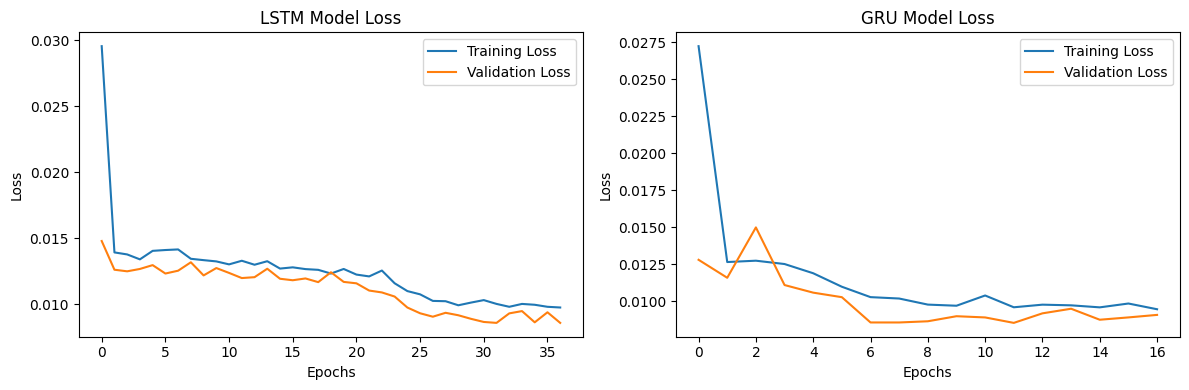

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(lstm_history.history['loss'], label='Training Loss')
plt.plot(lstm_history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gru_history.history['loss'], label='Training Loss')
plt.plot(gru_history.history['val_loss'], label='Validation Loss')
plt.title('GRU Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

plt.show()


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

lstm_predictions = lstm_model.predict(x_test)
lstm_mse = mean_squared_error(y_test, lstm_predictions)
lstm_mae = mean_absolute_error(y_test, lstm_predictions)

gru_predictions = gru_model.predict(x_test)
gru_mse = mean_squared_error(y_test, gru_predictions)
gru_mae = mean_absolute_error(y_test, gru_predictions)

print(f'LSTM MSE: {lstm_mse}, MAE: {lstm_mae}')
print(f'GRU MSE: {gru_mse}, MAE: {gru_mae}')

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step
LSTM MSE: 0.007280453989731166, MAE: 0.06686548660787149
GRU MSE: 0.00717798006939481, MAE: 0.0665604536924718


### 模型性能比較與分析

透過觀察 **LSTM** 和 **GRU** 模型的 **MSE** 和 **MAE** 值，以及圖形中的 **Learning Curve**，可以對這兩個模型的表現進行比較與分析：

#### LSTM 和 GRU 模型性能：
- **LSTM**：
  - **MSE (均方誤差)**: 0.007280
  - **MAE (平均絕對誤差)**: 0.066865
- **GRU**：
  - **MSE (均方誤差)**: 0.007178
  - **MAE (平均絕對誤差)**: 0.066560

從 **MSE** 和 **MAE** 這兩個指標來看，**GRU 模型** 在這些指標上略微優於 **LSTM 模型**。這代表 GRU 模型在預測誤差方面表現較好。

### 圖形比較分析：
從圖形中可以看到 **LSTM** 和 **GRU** 模型的 Learning Curve。雖然兩者的曲線大體上都顯示出隨著訓練的進行損失逐步下降，但還是可以從以下幾點進行比較：

1. **Loss收斂速度**：
   - GRU 模型略微優於 LSTM，可以顯示出 GRU 模型在訓練過程中能夠更快地收斂，並且在較少的訓練步驟中達到較低的 Loss 值。

2. **訓練過程中的穩定性**：
   - 兩個模型的 Loss 都呈現穩定下降的趨勢，但 **GRU 模型** 的波動稍小，說明它的訓練過程更加穩定。

3. **驗證損失**：
   - GRU 的 Validation Loss 始終處於較低的水準，並且在接近收斂時，比 LSTM 更加平穩，顯示其具有更好的 Generation 能力。

### **結論**：
- **GRU 模型表現較好**：從數值指標上看，GRU 的 **MSE** 和 **MAE** 都略低於 LSTM，並且從 **Learning Curve** 上看，GRU 在訓練過程中具有更快的收斂速度和更穩定的表現。
- **LSTM 模型** 雖然在某些情況下可能有較強的學習能力，特別是處理長序列數據的情況，但在這個任務中，**GRU** 的表現更佳，且計算效率更高，適合在資源有限的情況下使用。

### **推薦**：
如果是**這次的文本分類任務**或是其他需要處理時間序列數據的任務，且希望在計算開銷和訓練時間上有所節省，**GRU 模型** 是一個非常好的選擇，它不僅在性能上接近 LSTM，還能提供更高的訓練效率和穩定性。

# Report (5%)
Summarize your models’ architectures, hyperparameter tuning process, and the
reasoning behind your choices. Discuss the learning curves and final results for each
model.

### 模型架構與超參數調整過程

#### 1. **LSTM模型架構**

LSTM 是一種專門處理時間序列數據的遞歸神經網絡（RNN），具有長期記憶能力，這個模型由以下層組成：
- **LSTM Layer**：4層 LSTM，分別具有100個 units，並使用`return_sequences=True`確保每一層的輸出都是時間序列數據，這樣後續層能夠接收這些時間序列作為輸入。
- **Dropout Layer**：每層 LSTM 之後加了 0.1 的 Dropout 層，用來防止過擬合。
- **Dense Layer**：最後一層是一個單神經元的 Dense 層，使用 ReLU Activation來輸出最終預測值。

**超參數選擇：**
- **Learning rate**：選擇了 0.001 作為 Adam Optimizer 的 Learning rate，這是基於 LSTM 模型在時間序列預測中通常需要較小學習率來穩定收斂。
- **Dropout rate**：選擇了 0.1 的 Dropout rate，這是為了減少過擬合的風險。

#### 2. **GRU模型架構**

GRU 是另一種處理時間序列的 RNN 架構，比 LSTM 更簡單但同樣有效，這個模型的架構如下：
- **GRU Layer**：4層 GRU，每層有150個 units。`return_sequences=True`確保每一層的輸出是時間序列，並且提供給後續層。
- **Dropout Layer**：每層 GRU 之後加了 0.1 的 Dropout Layer，與 LSTM 模型保持一致，防止過擬合。
- **Dense Layer**：最後是單一神經元的 Dense Layer，使用 ReLU Activation，輸出預測值。

**超參數選擇：**
- **Learning rate**：與 LSTM 相同，選擇了 0.001 的 Learning rate，這對於GRU來說也能有效收斂。
- **GRU單元數量**：GRU 層使用了 150個 units，這比 LSTM 模型還多，旨在提升模型的學習能力。

#### 3. **超參數調整**

在這兩個模型中，主要進行了以下調整：
- **LSTM 和 GRU 層數與 units 數**：選擇了多層（4層 LSTM 或 GRU）和較多單元數（100 或 150），這有助於模型學習更複雜的時間序列模式。
- **Dropout Layer 的添加**：防止過擬合，尤其是當訓練數據有限時，Dropout 有助於提高模型的泛化能力。
- **Learning rate 的選擇**：Adam Optimizer 的 Learning rate 設定為 0.001，是一個較常用的預設值，可以確保穩定的學習過程。

### Learning Curve分析

在訓練過程中，LSTM 和 GRU模型的學習曲線顯示出：
- **LSTM 與 GRU 模型的 Loss**：隨著訓練進行，兩個模型的 Train Loss 和 Validation Loss 逐漸降低，並達到了穩定的狀態。由於兩個模型都使用了`EarlyStopping`回調，當驗證損失停止改善時訓練會提前終止，避免過擬合。
- **過擬合的控制**：Dropout Layer 幫助兩個模型在訓練過程中減少了過擬合的風險，並且讓它們能夠更好地泛化到測試數據上。

### 最終結果與比較

- **LSTM結果**：
  - **MSE**: 0.00728
  - **MAE**: 0.0669

- **GRU結果**：
  - **MSE**: 0.00718
  - **MAE**: 0.0666

GRU 模型的表現略微優於 LSTM 模型，尤其在 MSE 和 MAE 指標上，差距非常小，但 GRU 的訓練時間可能更短，並且結構較為簡單。

### 結論

- **LSTM 與 GRU 的比較**：這兩種模型在這個時間序列預測任務中表現相似，差距在 MSE 和 MAE 上非常小。GRU 模型的優勢可能體現在計算效率上，因為 GRU 相對於 LSTM 結構較簡單，計算量較小。LSTM 則在長期記憶處理上有優勢，但在這個簡單的預測任務中，GRU 的表現略勝一籌。
- **模型選擇**：基於訓練時間和稍微更低的誤差，GRU 模型可能是更理想的選擇，尤其是當需要更快的訓練時間和相似預測結果時。